In [1]:
# -*- coding: utf-8 -*-
"""
Created on 2026-06-22
Revised on 2026-06-22

@author:       Oscar Trevizo
@institution:  Harvard Extension School — Graduate Data Science Program (2023)
@context:      Independent project — applying course concepts to real-world data
@environment:  Python 3.14.3 | myenv | MacBook Air M5

Neurosymbolic AI — Credit Review Use Case
==========================================

Description:
    Demonstrates a neurosymbolic (hybrid) AI pattern: a machine learning
    layer produces a probabilistic signal, which a deterministic rules layer
    then converts into an auditable, per-row credit decision.

    Neural layer   — Linear regression predicts Balance from financial and
                     demographic predictors. Derived signal:
                     predicted_utilization = predicted_Balance / Limit.
    Symbolic layer — An explicit policy function (apply_policy) applies
                     ordered rules to every test-set row, producing a
                     final_decision (Approve / Review / Deny) and a
                     rule_fired field that makes each outcome auditable.

    Student status is deliberately withheld from the ML model and reserved
    for the rules layer — illustrating how domain knowledge and policy
    constraints enter the system separately from the statistical model.

    This notebook is a reusable reference pattern.

Key Concepts:
    Neural layer    — probabilistic signal from a trained regression model
    Symbolic layer  — deterministic, ordered rules applied post-model
    Auditability    — every decision carries the rule that fired it
    Hybrid AI       — ML signal + explicit rules working in tandem

Dataset:
    Credit {ISLR/ISLP} — simulated credit card dataset
    400 observations, 12 variables
    ML target:    Balance (continuous — regression)
    Rules input:  Student (Yes/No) — withheld from ML, used only in rules

Revision History:
    2026-06-22  Original development
                - Linear regression: Income, Limit, Rating, Cards, Age,
                  Education, Gender, Married → Balance
                - Derived signal: predicted_utilization = predicted_Balance / Limit
                - apply_policy() with data-driven cutoffs (p75/p90 of training-set
                  predicted_utilization); versioned and frozen as POLICY_V1
                - Model-only vs. hybrid comparison on borderline rows
"""

'\nCreated on 2026-06-22\nRevised on 2026-06-22\n\n@author:       Oscar Trevizo\n@institution:  Harvard Extension School — Graduate Data Science Program (2023)\n@context:      Independent project — applying course concepts to real-world data\n@environment:  Python 3.14.3 | myenv | MacBook Air M5\n\nNeurosymbolic AI — Credit Review Use Case\n==========================================\n\nDescription:\n    Demonstrates a neurosymbolic (hybrid) AI pattern: a machine learning\n    layer produces a probabilistic signal, which a deterministic rules layer\n    then converts into an auditable, per-row credit decision.\n\n    Neural layer   — Linear regression predicts Balance from financial and\n                     demographic predictors. Derived signal:\n                     predicted_utilization = predicted_Balance / Limit.\n    Symbolic layer — An explicit policy function (apply_policy) applies\n                     ordered rules to every test-set row, producing a\n                     fina

# Neurosymbolic AI — Credit Review Use Case

## Overview

This notebook demonstrates a **neurosymbolic (hybrid) AI** pattern — a machine
learning model feeds a signal into a deterministic rules layer that produces
the final, auditable decision.

```
Customer features ——► [ Neural Layer ]  ——► predicted_utilization
                         Linear Regression
                                                      │
                                                      ▼
                         [ Symbolic Layer ] ——► final_decision + rule_fired
                           apply_policy()             (Approve / Review / Deny)
```

**Why neurosymbolic?**
- Pure ML produces a score but the *decision* is implicit and opaque.
- Pure rules are auditable but brittle — they do not learn from data.
- Combining both gives the predictive power of ML with the transparency
  and regulatory auditability of explicit rules.

**Key design choice:** `Student` is withheld from the regression model and used
only in the rules layer — reflecting real-world scenarios where a sensitive
attribute cannot be a direct model input but can be an explicit, documented
policy consideration.

## Imports

In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from ISLP import load_data

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid')

# Harvard color palette
CRIMSON   = '#A51C30'
ROYALBLUE = '#002366'
SLATE     = '#8996A0'
IVY       = '#52854C'
SAFFRON   = '#D16103'
INDIGO    = '#293352'
SHADE     = '#BAC5C6'

print('Imports complete.')

Imports complete.


---

## Dataset: Credit {ISLR/ISLP}

The **Credit** dataset is a simulated dataset of 400 credit card holders with
financial variables (Income, Limit, Rating, Balance) and demographic variables
(Age, Gender, Student, Married, Ethnicity).

**ML target:** `Balance` (continuous — regression)\
**ML predictors:** `Income`, `Limit`, `Rating`, `Cards`, `Age`, `Education`, `Gender`, `Married`\
**Withheld from ML:** `Student` — reserved for the symbolic rules layer

In [3]:
Credit = load_data('Credit')

print(f'Shape: {Credit.shape}')
print()
print('dtypes:')
print(Credit.dtypes)

Shape: (400, 12)

dtypes:
ID              int64
Income        float64
Limit           int64
Rating          int64
Cards           int64
Age             int64
Education       int64
Gender       category
Student      category
Married      category
Ethnicity    category
Balance         int64
dtype: object


In [4]:
Credit.head()

,ID,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,1,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
1,2,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
2,3,104.593,7075,514,4,71,11,Male,No,No,Asian,580
3,4,148.924,9504,681,3,36,11,Female,No,No,Asian,964
4,5,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331


In [5]:
Credit.describe(include='all').round(2)

,ID,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
count,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400,400,400,400,400.00
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2,3,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Female,No,Yes,Caucasian,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,207,360,245,199,NaN
mean,200.50,45.22,4735.60,354.94,2.96,55.67,13.45,NaN,NaN,NaN,NaN,520.02
std,115.61,35.24,2308.20,154.72,1.37,17.25,3.13,NaN,NaN,NaN,NaN,459.76
min,1.00,10.35,855.00,93.00,1.00,23.00,5.00,NaN,NaN,NaN,NaN,0.00
25%,100.75,21.01,3088.00,247.25,2.00,41.75,11.00,NaN,NaN,NaN,NaN,68.75
50%,200.50,33.12,4622.50,344.00,3.00,56.00,14.00,NaN,NaN,NaN,NaN,459.50
75%,300.25,57.47,5872.75,437.25,4.00,70.00,16.00,NaN,NaN,NaN,NaN,863.00


---

## EDA

Two views that give context for the policy rules:
- **Utilization distribution** — actual Balance / Limit across the full dataset.
  Policy thresholds are derived later from the training-set *predicted* utilization,
  so no fixed markers are shown here.
- **Balance by Student status** — the variable that drives the Vulnerable segment rule.

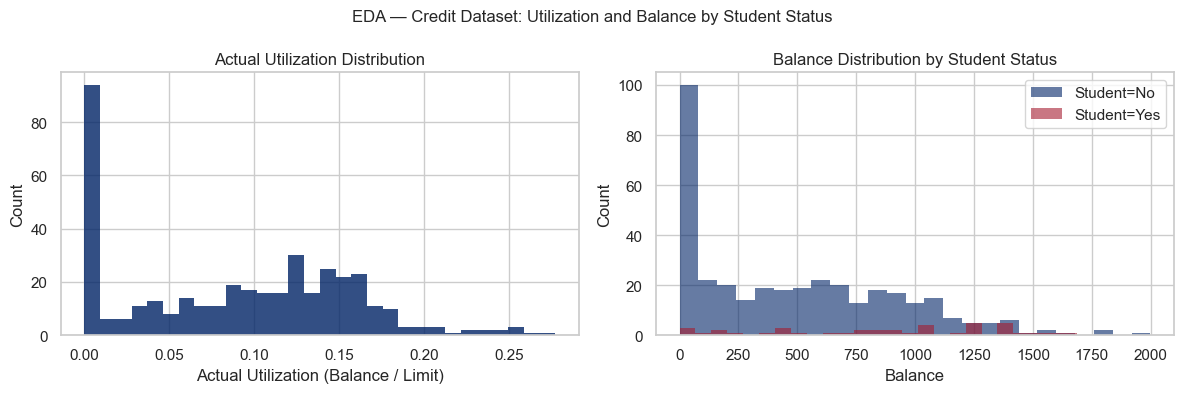

Actual utilization — descriptive stats:
count    400.0000
mean       0.0896
std        0.0676
min        0.0000
25%        0.0185
50%        0.0987
75%        0.1432
max        0.2769
Name: actual_utilization, dtype: float64

Students in dataset: 40 of 400
(Policy thresholds are derived from training-set predicted utilization — see Neural Layer section.)


In [6]:
Credit['actual_utilization'] = Credit['Balance'] / Credit['Limit']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(Credit['actual_utilization'], bins=30,
             color=ROYALBLUE, edgecolor='none', alpha=0.8)
axes[0].set_xlabel('Actual Utilization (Balance / Limit)')
axes[0].set_ylabel('Count')
axes[0].set_title('Actual Utilization Distribution')

palette = {'Yes': CRIMSON, 'No': ROYALBLUE}
for label, grp in Credit.groupby('Student', observed=True):
    axes[1].hist(grp['Balance'], bins=25, alpha=0.6,
                 color=palette[label], label=f'Student={label}', edgecolor='none')
axes[1].set_xlabel('Balance')
axes[1].set_ylabel('Count')
axes[1].set_title('Balance Distribution by Student Status')
axes[1].legend()

fig.suptitle('EDA — Credit Dataset: Utilization and Balance by Student Status', fontsize=12)
plt.tight_layout()
plt.show()

print('Actual utilization — descriptive stats:')
print(Credit['actual_utilization'].describe().round(4))
print()
n_stu = (Credit['Student'] == 'Yes').sum()
print(f'Students in dataset: {n_stu} of {len(Credit)}')
print('(Policy thresholds are derived from training-set predicted utilization — see Neural Layer section.)')

---

## Data Preparation

Encode binary categorical predictors (`Gender`, `Married`) for sklearn.
`Student` is carried in the dataframe but **not** included in `FEATURES` —
it will only be used by the symbolic layer.

In [7]:
FEATURES = ['Income', 'Limit', 'Rating', 'Cards', 'Age', 'Education', 'Gender', 'Married']
TARGET   = 'Balance'

Credit_enc = Credit[FEATURES + [TARGET, 'Student']].copy()

# Encode binary categoricals: Male=0 Female=1 | No=0 Yes=1
Credit_enc['Gender']  = (Credit_enc['Gender']  == 'Female').astype(int)
Credit_enc['Married'] = (Credit_enc['Married'] == 'Yes').astype(int)

print('Encoding: Gender Male=0 Female=1  |  Married No=0 Yes=1')
print(f'Shape: {Credit_enc.shape}')
Credit_enc.head()

Encoding: Gender Male=0 Female=1  |  Married No=0 Yes=1
Shape: (400, 10)


,Income,Limit,Rating,Cards,Age,Education,Gender,Married,Balance,Student
0,14.891,3606,283,2,34,11,0,1,333,No
1,106.025,6645,483,3,82,15,1,1,903,Yes
2,104.593,7075,514,4,71,11,0,0,580,No
3,148.924,9504,681,3,36,11,1,0,964,No
4,55.882,4897,357,2,68,16,0,1,331,No


## Train / Test Split

In [8]:
train_df, test_df = train_test_split(Credit_enc, test_size=0.3, random_state=1234)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test  = test_df[FEATURES]
y_test  = test_df[TARGET]

print(f'Train: {train_df.shape}   Test: {test_df.shape}')
print(f'Train Balance — mean: {y_train.mean():.2f}  std: {y_train.std():.2f}')
print(f'Test  Balance — mean: {y_test.mean():.2f}  std: {y_test.std():.2f}')

Train: (280, 10)   Test: (120, 10)
Train Balance — mean: 508.32  std: 454.65
Test  Balance — mean: 547.31  std: 472.26


---

## Neural Layer — Linear Regression

The ML model predicts `Balance` from financial and demographic predictors.
`Student` is deliberately excluded — it is not a model input.

The output is a continuous prediction. The derived signal that feeds the
symbolic layer is:

```
predicted_utilization = predicted_Balance / Limit
```

This is the bridge between the two layers.

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

coef_df = (pd.DataFrame({'Feature': FEATURES, 'Coefficient': model.coef_})
             .sort_values('Coefficient', key=abs, ascending=False))
print('Linear Regression — Coefficients (sorted by |magnitude|):')
print(coef_df.to_string(index=False))
print(f'\nIntercept: {model.intercept_:.4f}')

y_train_pred = model.predict(X_train)
print(f'\nTrain R²  : {r2_score(y_train, y_train_pred):.4f}')
print(f'Train RMSE: {mean_squared_error(y_train, y_train_pred)**0.5:.2f}')

# Calibrate thresholds from training set only — no leakage into test set
train_util    = np.clip(y_train_pred, 0, None) / train_df['Limit'].values
deny_cutoff   = float(np.quantile(train_util, 0.90))
review_cutoff = float(np.quantile(train_util, 0.75))

# Freeze as a versioned policy object — single source of truth for scoring
POLICY_V1 = {
    "deny_cutoff":    deny_cutoff,
    "review_cutoff":  review_cutoff,
    "effective_date": "2026-06-22",
    "note": "Calibrated once from training cohort; frozen for scoring.",
}

print(f'\nPOLICY_V1:')
for k, v in POLICY_V1.items():
    print(f'  {k}: {v}')

Linear Regression — Coefficients (sorted by |magnitude|):
  Feature  Coefficient
  Married   -35.667541
    Cards    14.248412
   Gender   -12.569444
   Income    -7.514381
Education     4.107863
   Rating     1.432366
      Age    -0.677540
    Limit     0.165966

Intercept: -460.2378

Train R²  : 0.8602
Train RMSE: 169.69

POLICY_V1:
  deny_cutoff: 0.15663252823255056
  review_cutoff: 0.13812474589965415
  effective_date: 2026-06-22
  note: Calibrated once from training cohort; frozen for scoring.


### Policy Governance — Calibrate Once, Freeze, Version

`POLICY_V1` packages the computed thresholds as a named, versioned artifact.

In this notebook the cutoffs are computed live from the training split for
demonstration. In production the pattern would be different:

1. **Calibration** (this step) runs once on a representative training cohort.
2. The resulting cutoffs are **reviewed, approved, and frozen** — not recomputed
   on every scoring run.
3. The frozen policy is versioned (`POLICY_V1`, `POLICY_V2`, …) so any change
   to thresholds is an explicit, auditable event.

Recomputing cutoffs on every run would let the meaning of "Deny" silently
drift as the training population changes — even when no individual customer's
actual risk has changed. That defeats the auditability the symbolic layer is
supposed to provide.

## Predict on Test Set — Derive Utilization Signal

In [10]:
y_pred = np.clip(model.predict(X_test), 0, None)   # balance cannot be negative

r2   = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae  = mean_absolute_error(y_test, y_pred)

print(f'Test R²  : {r2:.4f}')
print(f'Test RMSE: {rmse:.2f}')
print(f'Test MAE : {mae:.2f}')

# Build results frame — carry Limit and Student through from test set
results = test_df[['Limit', 'Student', TARGET]].copy()
results['predicted_balance']     = y_pred.round(2)
results['predicted_utilization'] = (results['predicted_balance'] / results['Limit']).round(4)

print(f'\nPredicted utilization — descriptive stats:')
print(results['predicted_utilization'].describe().round(4))

Test R²  : 0.9264
Test RMSE: 127.60
Test MAE : 87.29

Predicted utilization — descriptive stats:
count    120.0000
mean       0.1019
std        0.0564
min        0.0000
25%        0.0595
50%        0.1191
75%        0.1464
max        0.1784
Name: predicted_utilization, dtype: float64


---

## Symbolic Layer — Policy Function

`apply_policy()` takes a single row and applies three rules **in priority order**.
The first rule whose condition is satisfied fires; the remaining rules are skipped.

Thresholds are **data-driven**: computed from the training-set predicted utilization
distribution so the rules adapt to this dataset's actual scale.

| Priority | Rule | Condition | Decision |
|---|---|---|---|
| 1 | Hard cap | `predicted_utilization > deny_cutoff` (p90 of train) | Deny |
| 2 | Vulnerable segment | `Student == Yes` and `review_cutoff ≤ util ≤ deny_cutoff` (p75–p90) | Review |
| 3 | Default | none of the above | Approve |

The function returns both the decision **and** the rule that fired it —
making every outcome individually auditable.

In [11]:
def apply_policy(row, policy):
    """
    Symbolic rules layer — converts neural signal into an auditable credit decision.

    Rules applied in priority order; first match wins.
    Accepts a versioned policy object so scoring always applies a frozen,
    reviewed set of thresholds rather than inline constants.

    Parameters
    ----------
    row : pd.Series
        Must contain 'predicted_utilization' (float) and 'Student' ('Yes'/'No').
    policy : dict
        Versioned policy object with 'deny_cutoff' and 'review_cutoff' keys.

    Returns
    -------
    tuple of (decision: str, rule_fired: str)
    """
    util          = row['predicted_utilization']
    deny_cutoff   = policy['deny_cutoff']
    review_cutoff = policy['review_cutoff']

    if util > deny_cutoff:
        return ('Deny',    f'Hard cap: util={util:.4f} > deny_cutoff={deny_cutoff:.4f} (p90)')
    elif row['Student'] == 'Yes' and review_cutoff <= util <= deny_cutoff:
        return ('Review',  f'Vulnerable segment: Student + util={util:.4f} in [{review_cutoff:.4f}, {deny_cutoff:.4f}] (p75–p90)')
    else:
        return ('Approve', 'Default: no rule fired')


print('apply_policy() defined — accepts POLICY_V1 object.')
print()
print('Sanity checks:')
dc = POLICY_V1["deny_cutoff"]
rc = POLICY_V1["review_cutoff"]
test_cases = [
    {'predicted_utilization': dc + 0.01, 'Student': 'No'},
    {'predicted_utilization': (rc + dc) / 2, 'Student': 'Yes'},
    {'predicted_utilization': (rc + dc) / 2, 'Student': 'No'},
    {'predicted_utilization': rc - 0.01, 'Student': 'Yes'},
]
labels = ['above deny_cutoff (No)', 'mid-band (Yes)', 'mid-band (No)', 'below review_cutoff (Yes)']
for tc, lbl in zip(test_cases, labels):
    d, r = apply_policy(pd.Series(tc), POLICY_V1)
    print(f'  {lbl:35s} →  {d:7s}')

apply_policy() defined — accepts POLICY_V1 object.

Sanity checks:
  above deny_cutoff (No)              →  Deny   
  mid-band (Yes)                      →  Review 
  mid-band (No)                       →  Approve
  below review_cutoff (Yes)           →  Approve


## Apply Policy — Build Results

In [12]:
decisions = results.apply(lambda row: apply_policy(row, POLICY_V1), axis=1)
results['final_decision'] = decisions.apply(lambda x: x[0])
results['rule_fired']     = decisions.apply(lambda x: x[1])

print('Decision distribution (test set):')
print(results['final_decision'].value_counts())
print()
display_cols = ['Limit', 'Student', TARGET, 'predicted_balance',
                'predicted_utilization', 'final_decision', 'rule_fired']
print('Sample rows (10):')
print(results[display_cols].sample(10, random_state=42).to_string())

Decision distribution (test set):
final_decision
Approve    100
Deny        17
Review       3
Name: count, dtype: int64

Sample rows (10):
     Limit Student  Balance  predicted_balance  predicted_utilization final_decision                                        rule_fired
44    4865      No      836             859.42                 0.1767           Deny  Hard cap: util=0.1767 > deny_cutoff=0.1566 (p90)
47    4756      No      594             648.30                 0.1363        Approve                            Default: no rule fired
4     1626      No        0               0.00                 0.0000        Approve                            Default: no rule fired
55    3484      No      265             413.43                 0.1187        Approve                            Default: no rule fired
26    2000      No        0               0.00                 0.0000        Approve                            Default: no rule fired
64    2073      No        0               0.00     

## Decision Distribution

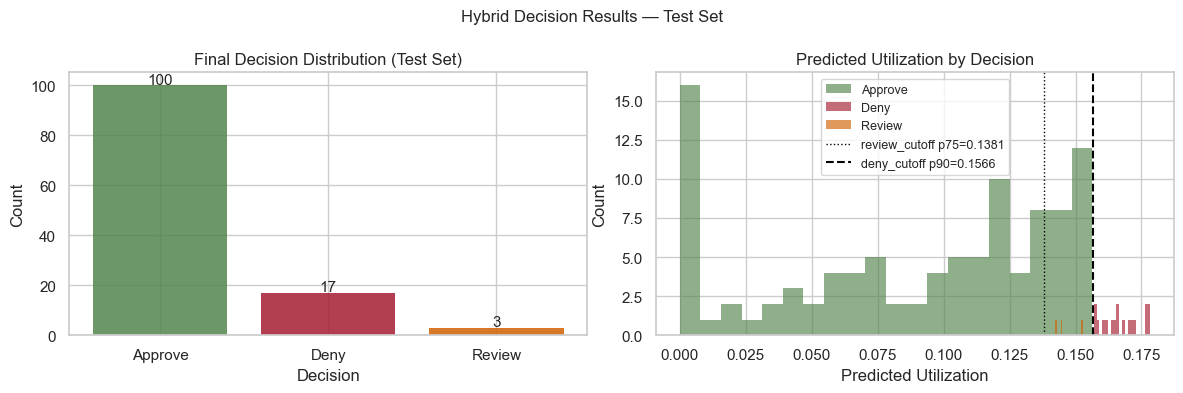

In [13]:
decision_colors = {'Approve': IVY, 'Review': SAFFRON, 'Deny': CRIMSON}
counts = results['final_decision'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(counts.index, counts.values,
            color=[decision_colors[d] for d in counts.index],
            edgecolor='none', alpha=0.85)
for i, (d, v) in enumerate(counts.items()):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontsize=11)
axes[0].set_xlabel('Decision')
axes[0].set_ylabel('Count')
axes[0].set_title('Final Decision Distribution (Test Set)')

for decision, grp in results.groupby('final_decision'):
    axes[1].hist(grp['predicted_utilization'], bins=20, alpha=0.65,
                 color=decision_colors[decision], label=decision, edgecolor='none')
axes[1].axvline(POLICY_V1['review_cutoff'], color='black', linestyle=':',  linewidth=1,
                label=f'review_cutoff p75={POLICY_V1["review_cutoff"]:.4f}')
axes[1].axvline(POLICY_V1['deny_cutoff'],   color='black', linestyle='--', linewidth=1.5,
                label=f'deny_cutoff p90={POLICY_V1["deny_cutoff"]:.4f}')
axes[1].set_xlabel('Predicted Utilization')
axes[1].set_ylabel('Count')
axes[1].set_title('Predicted Utilization by Decision')
axes[1].legend(fontsize=9)

fig.suptitle('Hybrid Decision Results — Test Set', fontsize=12)
plt.tight_layout()
plt.show()

---

## Model-Only vs. Hybrid Comparison

A **model-only baseline** applies a single hard threshold:
`predicted_utilization > deny_cutoff` → Deny, else → Approve.
No Review tier, no Student consideration.

The rows below are where the two systems **disagree** — these are exactly the
cases where the symbolic layer adds value beyond the statistical model alone.

In [14]:
results['model_only_decision'] = results['predicted_utilization'].apply(
    lambda u: 'Deny' if u > POLICY_V1['deny_cutoff'] else 'Approve'
)

borderline = results[results['final_decision'] != results['model_only_decision']].copy()

print(f'Rows where hybrid overrides model-only: {len(borderline)} of {len(results)} test rows')
print()
cols = ['Student', 'Limit', TARGET, 'predicted_balance',
        'predicted_utilization', 'model_only_decision', 'final_decision', 'rule_fired']
print(borderline[cols].to_string(index=True))

Rows where hybrid overrides model-only: 3 of 120 test rows

    Student  Limit  Balance  predicted_balance  predicted_utilization model_only_decision final_decision                                                               rule_fired
23      Yes   6045     1425             923.30                 0.1527             Approve         Review  Vulnerable segment: Student + util=0.1527 in [0.1381, 0.1566] (p75–p90)
102     Yes   5765     1246             833.17                 0.1445             Approve         Review  Vulnerable segment: Student + util=0.1445 in [0.1381, 0.1566] (p75–p90)
109     Yes   6784     1411             965.20                 0.1423             Approve         Review  Vulnerable segment: Student + util=0.1423 in [0.1381, 0.1566] (p75–p90)


---

## Summary and Key Takeaways

In [15]:
print('Neurosymbolic Credit Review — Final Summary')
print(f'  Dataset             : Credit {{ISLR/ISLP}}, n={len(Credit)}')
print(f'  ML target           : Balance (regression)')
print(f'  ML predictors       : {FEATURES}')
print(f'  Student withheld    : used only in symbolic layer')
print(f'  Test set size       : {len(results)} observations')
print()
print('Neural layer (Linear Regression):')
print(f'  Test R²             : {r2:.4f}')
print(f'  Test RMSE           : {rmse:.2f}')
print(f'  Test MAE            : {mae:.2f}')
print()
print('Symbolic layer — final decision distribution:')
for d, c in results['final_decision'].value_counts().items():
    pct = c / len(results) * 100
    print(f'  {d:7s}: {c:3d}  ({pct:.1f}%)')
print()
print(f'Hybrid overrode model-only on: {len(borderline)} rows')

Neurosymbolic Credit Review — Final Summary
  Dataset             : Credit {ISLR/ISLP}, n=400
  ML target           : Balance (regression)
  ML predictors       : ['Income', 'Limit', 'Rating', 'Cards', 'Age', 'Education', 'Gender', 'Married']
  Student withheld    : used only in symbolic layer
  Test set size       : 120 observations

Neural layer (Linear Regression):
  Test R²             : 0.9264
  Test RMSE           : 127.60
  Test MAE            : 87.29

Symbolic layer — final decision distribution:
  Approve: 100  (83.3%)
  Deny   :  17  (14.2%)
  Review :   3  (2.5%)

Hybrid overrode model-only on: 3 rows


## Key Takeaways

1. **Separation of concerns:** The ML model handles the statistical task (predict
   Balance → utilization signal). The rules layer handles the policy task (what
   to do given that signal and domain context). Neither layer needs the internals
   of the other.

2. **Auditability:** Every row carries `rule_fired` — the exact rule that
   determined the outcome. This is a direct audit trail, something a standalone
   ML model cannot provide.

3. **Calibrate once, freeze, version:** `POLICY_V1` packages the thresholds as
   a named, versioned artifact. Recomputing cutoffs on every scoring run would
   let the meaning of "Deny" silently drift as the population changes — even
   when no individual customer's risk has changed. Freezing the policy makes
   threshold changes explicit and auditable.

4. **Student as a policy variable, not a model feature:** Withholding `Student`
   from regression and using it only in `apply_policy()` models a real-world
   constraint — sensitive attributes may be off-limits as model inputs but can
   be explicit, documented policy considerations.

5. **The Review tier adds value:** A model-only baseline has only Approve/Deny.
   The hybrid adds a Review tier for the highest-risk ambiguous segment —
   capturing cases a flat cutoff would either over-approve or over-deny.

6. **Extensibility:** Adding a new rule means adding a new `elif` branch to
   `apply_policy()` — no model retraining, no data pipeline changes. The two
   layers evolve independently.